# A/B Testing Toolkit — A Worked Example

This notebook walks through a complete, statistically rigorous A/B experiment analysis
using `ab-testing-toolkit`, from planning to platform validation. It is meant to read as
a story: *why* each step matters, not just *how* to call the API.

**Contents**
1. The problem — why rigorous analysis matters
2. Setting up an experiment
3. Running the analysis
4. Pre-experiment planning (power)
5. Multiple experiments (corrections)
6. Sequential testing (valid early stopping)
7. Platform validation (A/A testing)

## 1. The problem

An A/B test looks deceptively simple: ship two variants, compare a metric, pick the
winner. In practice, most of the ways a test can mislead you are statistical:

- **P-hacking / peeking** — checking results repeatedly and stopping at the first
  "significant" moment inflates the false-positive rate far beyond the nominal 5%.
- **Ignoring power** — an underpowered test that comes back "not significant" tells you
  almost nothing; you never had a real chance of detecting the effect.
- **Multiple comparisons** — test enough metrics or variants and some will look like
  winners by pure chance.
- **Broken randomization** — a sample-ratio mismatch quietly invalidates the whole test.

This toolkit provides the standard defenses against each of these. We'll use them all.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

import abtesting
print(f"ab-testing-toolkit v{abtesting.__version__}")

ab-testing-toolkit v0.1.0


## 2. Setting up an experiment

Imagine a streaming product testing a new homepage layout. The metric is **weekly hours
watched per user** — a continuous, right-skewed metric. We simulate a control group and a
treatment group with a genuine but modest lift.

In [14]:
from abtesting import Experiment

rng = np.random.default_rng(42)
n_per_arm = 4_000

# Watch time ~ lognormal (right-skewed). Treatment shifts the distribution up slightly.
control = rng.lognormal(mean=2.0, sigma=0.6, size=n_per_arm)
treatment = rng.lognormal(mean=2.06, sigma=0.6, size=n_per_arm)

exp = Experiment(control, treatment, metric_type="continuous")
summary = exp.summary()
for k, v in summary.items():
    print(f"{k:>16}: {v:.4f}" if isinstance(v, float) else f"{k:>16}: {v}")

     metric_type: continuous
       n_control: 4000
     n_treatment: 4000
    control_mean: 8.7432
  treatment_mean: 9.4085
     control_std: 5.7419
   treatment_std: 6.2357
 absolute_effect: 0.6653
   relative_lift: 0.0761


**Always check randomization first.** Before looking at the metric, confirm the
assignment split matches what we intended (here, 50/50). A significant sample-ratio
mismatch (SRM) means a logging or bucketing bug — stop and fix it before trusting anything.

In [15]:
from abtesting.utils import check_sample_ratio_mismatch

srm = check_sample_ratio_mismatch(exp.n_control, exp.n_treatment, expected_split=0.5)
print(f"SRM check: p={srm.p_value:.3f}  mismatch={srm.is_mismatch}")
print("Randomization looks healthy — safe to proceed." if not srm.is_mismatch
      else "STOP: investigate the assignment pipeline.")

SRM check: p=1.000  mismatch=False
Randomization looks healthy — safe to proceed.


## 3. Running the analysis

We use **Welch's t-test** (unequal variances — the correct default for A/B tests) on the
mean difference, then cross-check with a **bootstrap** confidence interval that makes no
normality assumption. For a skewed metric, agreement between the two is reassuring.

In [16]:
result = exp.ttest()
print(f"Test:            {result.test_name}")
print(f"p-value:         {result.p_value:.4g}")
print(f"significant:     {result.is_significant} (alpha={result.alpha})")
print(f"effect (Cohen d): {result.effect_size:.3f}")
print(f"relative lift:   {result.relative_lift:+.2%}")
print(f"95% CI on diff:  ({result.confidence_interval[0]:.3f}, {result.confidence_interval[1]:.3f})")

boot = exp.bootstrap_ci(n_bootstrap=10_000, random_state=0)
print(f"bootstrap 95% CI: ({boot[0]:.3f}, {boot[1]:.3f})")

Test:            Welch's t-test
p-value:         7.059e-07
significant:     True (alpha=0.05)
effect (Cohen d): 0.111
relative lift:   +7.61%
95% CI on diff:  (0.403, 0.928)
bootstrap 95% CI: (0.407, 0.929)


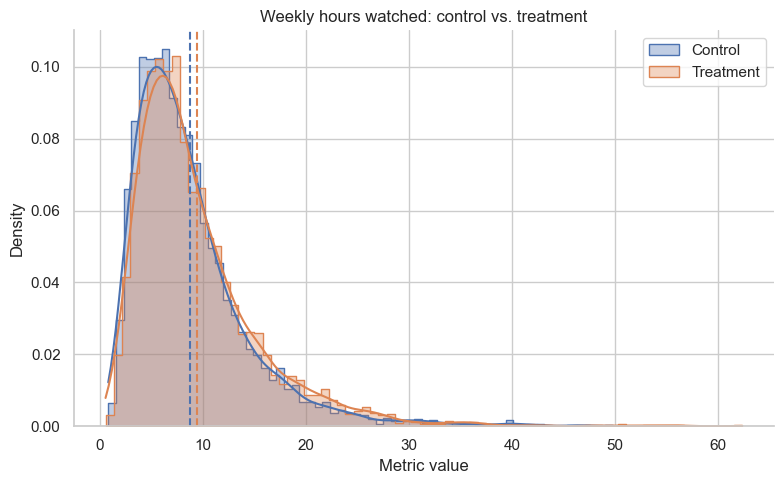

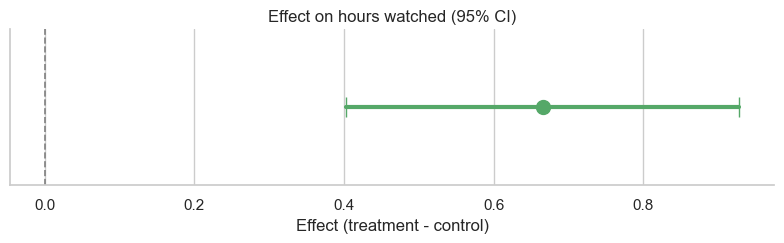

In [17]:
from abtesting import plot_distributions, plot_confidence_interval

fig1 = plot_distributions(exp, title="Weekly hours watched: control vs. treatment")
fig2 = plot_confidence_interval(result, title="Effect on hours watched (95% CI)")
plt.show()

The distributions overlap heavily (the effect is small relative to the spread), but with
4,000 users per arm the mean difference is estimated precisely enough that the confidence
interval clears zero. The bootstrap and parametric intervals agree closely, which gives us
confidence the t-test's normality approximation is fine at this sample size.

### Binary metrics

Conversion-style metrics (signed up? clicked?) use a proportion test instead. The API is
the same — just pass `metric_type="binary"` and call `chi_squared()`.

In [18]:
c_signup = rng.binomial(1, 0.20, 6_000)
t_signup = rng.binomial(1, 0.225, 6_000)
signup_exp = Experiment(c_signup, t_signup, metric_type="binary")
signup_res = signup_exp.chi_squared()
print(f"Conversion: {signup_res.p_value:.4g} p-value, significant={signup_res.is_significant}")
print(f"  lift in conversion rate: {signup_res.relative_lift:+.1%}")
signup_exp.to_dataframe()[["test_name", "statistic", "p_value", "is_significant", "relative_lift"]]

Conversion: 1.636e-08 p-value, significant=True
  lift in conversion rate: +22.0%


,test_name,statistic,p_value,is_significant,relative_lift
0,Chi-squared test,31.884139,1.636480e-08,True,0.220383


## 4. Pre-experiment planning

The analysis above only worked because the test was adequately powered. *Before* launching,
you should decide the sample size from the smallest effect worth detecting (the minimum
detectable effect, MDE) and translate that into a runtime given your traffic.

In [19]:
from abtesting import minimum_sample_size, experiment_runtime_days, observed_power

baseline = 0.20  # 20% baseline signup rate
for mde in (0.01, 0.02, 0.03):
    n = minimum_sample_size(baseline, mde, alpha=0.05, power=0.80)
    days = experiment_runtime_days(50_000, baseline, mde)
    print(f"MDE {mde:+.0%}: need {n:,} per arm  ->  {days} day(s) at 50k/day")

MDE +1%: need 25,580 per arm  ->  2 day(s) at 50k/day
MDE +2%: need 6,507 per arm  ->  1 day(s) at 50k/day
MDE +3%: need 2,940 per arm  ->  1 day(s) at 50k/day


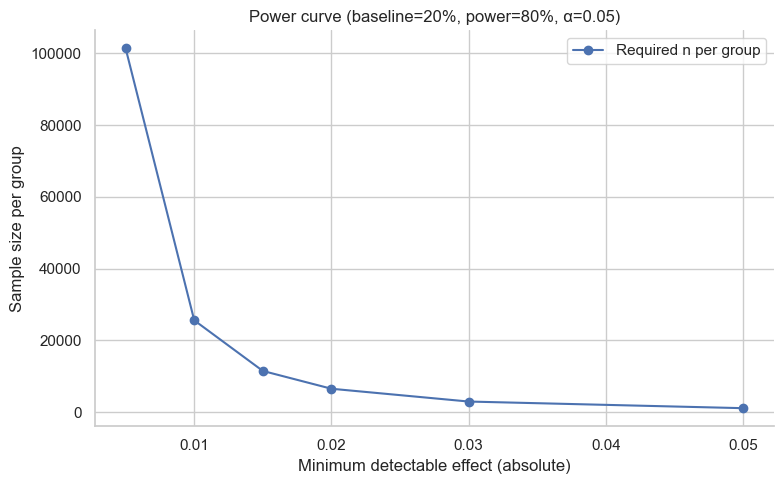

Observed power of the hours-watched test: 1.00


In [20]:
from abtesting import plot_power_curve

fig = plot_power_curve(baseline, [0.005, 0.01, 0.015, 0.02, 0.03, 0.05])
plt.show()

# Post-hoc: how well-powered was our continuous experiment?
power = observed_power(n=n_per_arm, effect_size=summary["absolute_effect"],
                       baseline_std=summary["control_std"])
print(f"Observed power of the hours-watched test: {power:.2f}")

The power curve makes the core planning tradeoff visible: halving the MDE roughly
**quadruples** the required sample size. Detecting tiny effects is expensive.

## 5. Multiple experiments

Teams rarely run one test at a time. Suppose we launch **20 simultaneous experiments**, all
of which are truly null (no effect). With no correction, the naive `p < 0.05` rule will
still flag roughly one "winner" by chance. Corrections fix this.

In [21]:
from abtesting import bonferroni, holm_bonferroni, benjamini_hochberg

rng2 = np.random.default_rng(2027)
p_values = [
    Experiment(rng2.normal(0, 1, 1_500), rng2.normal(0, 1, 1_500)).ttest().p_value
    for _ in range(20)
]
print(f"Naive 'winners' (p<0.05) among 20 null tests: {sum(p < 0.05 for p in p_values)}")
print(f"smallest raw p-value: {min(p_values):.4f}\n")

for name, res in [("Bonferroni (FWER)", bonferroni(p_values)),
                   ("Holm (FWER)", holm_bonferroni(p_values)),
                   ("Benjamini-Hochberg (FDR)", benjamini_hochberg(p_values))]:
    print(f"{name:28s} -> {res.n_rejected} rejected")

Naive 'winners' (p<0.05) among 20 null tests: 1
smallest raw p-value: 0.0268

Bonferroni (FWER)            -> 0 rejected
Holm (FWER)                  -> 0 rejected
Benjamini-Hochberg (FDR)     -> 0 rejected


**Which correction?** Bonferroni and Holm control the *family-wise error rate* (the chance
of **any** false positive) — use them when a single false positive is costly and the number
of tests is small; prefer Holm, which is uniformly more powerful. Benjamini-Hochberg
controls the *false discovery rate* (the expected **proportion** of false positives among
your rejections) — use it when screening many experiments, where some false discoveries are
an acceptable price for much more power.

## 6. Sequential testing

The most common way to ship a false win is **peeking**: monitoring a running experiment and
stopping the instant `p < 0.05`. Each look is another chance to cross the line by luck, so
the real false-positive rate balloons. Let's quantify it, then fix it.

In [22]:
from abtesting import always_valid_pvalue
from scipy import stats

rng3 = np.random.default_rng(7)
trials, n_max, step = 400, 2_000, 40
naive_fp = avp_fp = 0
for _ in range(trials):
    c = rng3.normal(0, 1, n_max)
    t = rng3.normal(0, 1, n_max)  # A/A: truly no effect
    naive_hit = avp_hit = False
    for n in range(step, n_max + 1, step):
        if not naive_hit and stats.ttest_ind(t[:n], c[:n], equal_var=False).pvalue < 0.05:
            naive_hit = True
        if not avp_hit and always_valid_pvalue(c[:n], t[:n]) < 0.05:
            avp_hit = True
    naive_fp += naive_hit
    avp_fp += avp_hit
print(f"Peeking 50x at a TRUE NULL experiment:")
print(f"  naive t-test false-positive rate:   {naive_fp/trials:.1%}  (should be 5%)")
print(f"  always-valid p false-positive rate: {avp_fp/trials:.1%}  (stays controlled)")

Peeking 50x at a TRUE NULL experiment:
  naive t-test false-positive rate:   31.5%  (should be 5%)
  always-valid p false-positive rate: 1.2%  (stays controlled)


The naive approach is wildly miscalibrated; the always-valid (mSPRT) p-value stays near the
nominal 5% no matter how often you look. For binary metrics, **Wald's SPRT** gives an
explicit stop/continue decision. Below we watch its log-likelihood ratio climb past the
"reject null" boundary as a real lift accumulates.

SPRT would stop and reject the null at n = 500 (vs a fixed test that waits for the full sample).


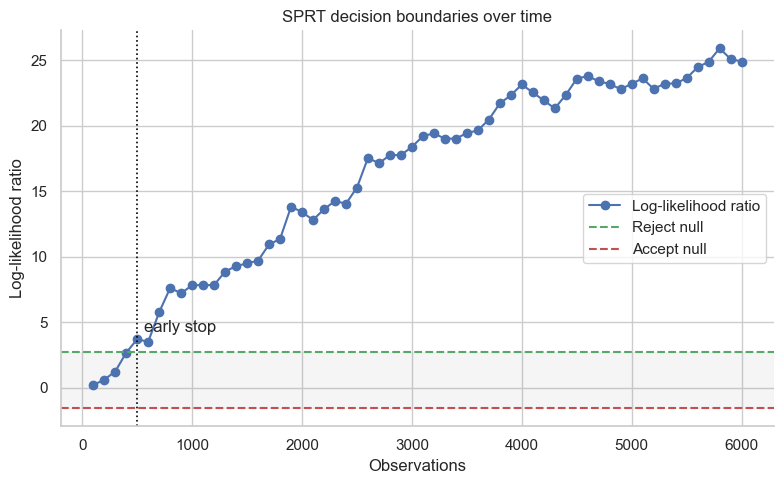

In [23]:
from abtesting import sprt, plot_sequential_boundaries

rng4 = np.random.default_rng(99)
stream = rng4.binomial(1, 0.13, 6_000)  # true rate 13% vs 10% null
cum = np.cumsum(stream)
obs = list(range(100, 6_001, 100))
results = [sprt(0, 1, int(cum[n - 1]), n, h0_rate=0.10, h1_rate=0.12) for n in obs]

first_stop = next((n for n, r in zip(obs, results) if r.decision == "reject_null"), None)
print(f"SPRT would stop and reject the null at n = {first_stop} (vs a fixed test that waits for the full sample).")
fig = plot_sequential_boundaries(results, obs)
plt.show()

## 7. Platform validation (A/A testing)

How do you know your experimentation *platform* is trustworthy? Run **A/A tests** — both
arms get the identical experience — and inspect the p-values. Under the null, p-values must
be **uniform on [0, 1]**. A non-uniform distribution is a red flag for a bug in
randomization, logging, or the analysis itself.

Fraction of 1,000 A/A tests with p<0.05: 5.2%  (expected ~5%)


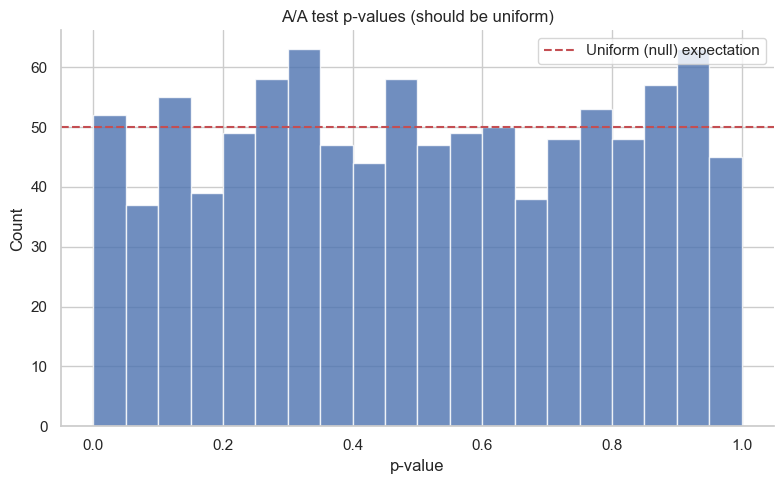

In [24]:
from abtesting import plot_pvalue_distribution

rng5 = np.random.default_rng(123)
aa_pvalues = [
    Experiment(rng5.normal(0, 1, 1_000), rng5.normal(0, 1, 1_000)).ttest().p_value
    for _ in range(1_000)
]
frac_sig = np.mean([p < 0.05 for p in aa_pvalues])
print(f"Fraction of 1,000 A/A tests with p<0.05: {frac_sig:.1%}  (expected ~5%)")
fig = plot_pvalue_distribution(aa_pvalues, title="A/A test p-values (should be uniform)")
plt.show()

The p-values are flat and the false-positive rate sits right at 5% — the platform is
well-calibrated.

---

### Recap

A trustworthy experiment program is a pipeline of defenses: **plan** for adequate power,
**check** randomization, **analyze** with the right test and an honest confidence interval,
**correct** for multiple comparisons, **stop early** only with sequentially valid methods,
and continuously **validate** the platform with A/A tests. `ab-testing-toolkit` packages
each of these into a small, well-tested API.